In [19]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
import librosa
import matplotlib.pyplot as plt
import librosa.display
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

In [20]:
def create_mfcc(segmented_dir, n_mfcc=13, hop_length=512):
    segmented_dir = Path(segmented_dir)
    X = []
    y = []
    labels = [f.name for f in segmented_dir.iterdir() if f.is_dir()]

    for label in tqdm(labels):
        for audio in (segmented_dir / label).iterdir():
            if audio.suffix == ".wav":
                signal, sr = librosa.load(audio, sr=None)
                n_fft = min(2048, len(signal))
                mfcc = librosa.feature.mfcc(y=signal, 
                                            sr=sr, 
                                            n_mfcc=n_mfcc, 
                                            n_fft=n_fft, 
                                            hop_length=hop_length)
                # mfcc_db = librosa.power_to_db(mfcc**2)
                # mfcc_list.append(mfcc_db)
                X.append(mfcc)
                y.append(label)

    X = np.array(X)
    X = np.expand_dims(X, axis=-1)

    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y)

    return X, np.array(y), label_encoder

Import data for model

In [ ]:
X, y, label_encoder = create_mfcc('IRMAS_segmented')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=1)

100%|██████████| 11/11 [01:15<00:00,  6.86s/it]


Plot MFCC

In [22]:
def plot_mfcc(X, i=0):
    mfcc_sample = X[i, :, :, 0]
    librosa.display.specshow(mfcc_sample, x_axis='time', y_axis='mel', cmap='viridis')
    plt.colorbar(label='Amplitude')
    plt.title('MFCC')
    plt.xlabel('Time Frames')
    plt.ylabel('MFCC Coefficients')
    plt.show()

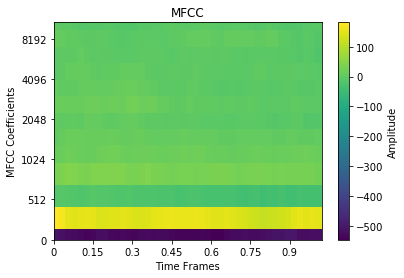

In [23]:
plot_mfcc(X)

CNN model

In [24]:
# cnn = models.Sequential([
#     layers.Conv2D(filters=16, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(X_train.shape[1], X_train.shape[2], 1)),
#     layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
#     layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'),
#     layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
#     layers.Flatten(),
#     layers.Dense(64, activation='relu'),
#     layers.Dense(len(musical_instruments), activation='softmax')
# ])

cnn = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(X.shape[1], X.shape[2], 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.25),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.25),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(np.unique(y)), activation='softmax')
])

cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

cnn.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_8 (Conv2D)            (None, 13, 44, 32)        320       
_________________________________________________________________
batch_normalization_8 (Batch (None, 13, 44, 32)        128       
_________________________________________________________________
max_pooling2d_8 (MaxPooling2 (None, 7, 22, 32)         0         
_________________________________________________________________
dropout_10 (Dropout)         (None, 7, 22, 32)         0         
_________________________________________________________________
conv2d_9 (Conv2D)            (None, 7, 22, 64)         18496     
_________________________________________________________________
batch_normalization_9 (Batch (None, 7, 22, 64)         256       
_________________________________________________________________
max_pooling2d_9 (MaxPooling2 (None, 4, 11, 64)        

Train CNN

In [ ]:
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

cnn.fit(X_train, y_train, epochs=100, validation_data=(X_val, y_val), callbacks=[early_stopping])

Epoch 1/80
403/403 [==============================] - 6s 15ms/step - loss: 2.1877 - accuracy: 0.2438 - val_loss: 1.9105 - val_accuracy: 0.3573
Epoch 2/80
403/403 [==============================] - 6s 15ms/step - loss: 2.0073 - accuracy: 0.3134 - val_loss: 1.8167 - val_accuracy: 0.4070
Epoch 3/80
403/403 [==============================] - 6s 15ms/step - loss: 1.9235 - accuracy: 0.3451 - val_loss: 1.7339 - val_accuracy: 0.4175
Epoch 4/80
403/403 [==============================] - 6s 15ms/step - loss: 1.8501 - accuracy: 0.3833 - val_loss: 1.6697 - val_accuracy: 0.4433
Epoch 5/80
403/403 [==============================] - 6s 15ms/step - loss: 1.7821 - accuracy: 0.4013 - val_loss: 1.6283 - val_accuracy: 0.4731
Epoch 6/80
403/403 [==============================] - 6s 15ms/step - loss: 1.7269 - accuracy: 0.4232 - val_loss: 1.5882 - val_accuracy: 0.4772
Epoch 7/80
403/403 [==============================] - 6s 15ms/step - loss: 1.6638 - accuracy: 0.4501 - val_loss: 1.6204 - val_accuracy: 0.4713

Evaluate CNN

In [26]:
y_pred = cnn.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

y_pred_labels = label_encoder.inverse_transform(y_pred)
y_test_labels = label_encoder.inverse_transform(y_test)

accuracy = accuracy_score(y_test_labels, y_pred_labels)
class_report = classification_report(y_test_labels, y_pred_labels)

print('Accuracy:', accuracy)
print('\nClassification Report:\n', class_report)

# output_file = 'cnn_mfcc_evaluation.txt'

# with open(output_file, 'w') as file:
#     file.write(f'Accuracy: {accuracy}\n')
#     file.write('\nClassification Report:\n')
#     file.write(class_report)

# best .73

Accuracy: 0.6955008699975143

Classification Report:
               precision    recall  f1-score   support

         cel       0.59      0.79      0.67       233
         cla       0.70      0.65      0.67       303
         flu       0.55      0.54      0.54       271
         gac       0.73      0.80      0.76       382
         gel       0.66      0.71      0.69       456
         org       0.75      0.74      0.74       409
         pia       0.69      0.74      0.72       432
         sax       0.68      0.52      0.59       376
         tru       0.78      0.72      0.74       346
         vio       0.67      0.62      0.64       348
         voi       0.80      0.77      0.78       467

    accuracy                           0.70      4023
   macro avg       0.69      0.69      0.69      4023
weighted avg       0.70      0.70      0.69      4023



Save CNN

In [27]:
# cnn.save('cnn_mfcc_model.h5')